In [1]:
import ODESolve_slow as ODE
from constants import mN
import numpy as np
import thermodynamics as thermo
from constants import me, mpl, zeta3
import weakrates as weak
import expansion as ex
import nseabundance as nse
import derivatives as der
import matplotlib.pyplot as plt
import xy_reactions as xy
import xgamma_reactions as xg

In [2]:
MeVtoT9 = 11604525006.1657/10**9

In [3]:
cmgstoMeV = 1.52e-16

In [7]:
def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN

In [8]:
def tpga(T):
    T9 = T*MeVtoT9
    F = T9**(-2/3)*2.2e4*np.exp(-3.869/(T9**(1/3)))*((T9**(1/3))*0.108+1.+(T9**(2/3))*1.68+T9*1.26+(T9**(4/3))*0.551+(T9**(5/3))*1.06)

    return F*cmgstoMeV*mN

In [11]:

# nB = eta*(3/2)*zeta3*T**3
# gammaf=(f[12]*nb)/mN

In [13]:
PNGD_INDEX = 0
TPGA_INDEX = 1

In [15]:
def sep(z):
    return z[0], z[1], z[2], z[3:]
T,t,eta,A = sep(np.arange(12))

#creates array of 12 dependent variables
def depvar(T,t,eta,A):
    return np.concatenate((np.array([T,t,eta]), A))

def pngd(T):
    T9 = T*MeVtoT9
    if T9<=1.5:
        F = 44216.*(1+3.75191*T9+1.92934*T9*T9+0.746503*T9*T9*T9+0.0197023*(T9**4)+3.00491e-6*(T9**5))/(1+5.4678*T9+5.62395*T9*T9+0.489312*T9*T9*T9+0.00747806*(T9**4))
    else:
        F = (1.-np.sqrt(T9)*0.8504+T9*0.4895-(T9**(3/2))*0.09623+T9*0.008471*T9-T9*2.8e-4*(T9**(3/2)))*47420
    return F*cmgstoMeV*mN
    

def f(a,y,p):
    T, t, eta, A = sep(y)
    nB = eta*(3/2)*zeta3*T**3
    Gamma_f = np.zeros(2)
    Gamma_f[PNGD_INDEX] = pngd(T)*nB
    Gamma_f[TPGA_INDEX] = tpga(T)*nB
    A_NSE = nse.nse(T, eta, A[nse.P_INDEX], A[nse.N_INDEX])
    Gamma_r = np.zeros(len(Gamma_f))
    Gamma_r[PNGD_INDEX] = Gamma_f[PNGD_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
    Gamma_r[TPGA_INDEX] = Gamma_f[TPGA_INDEX]*((nse.Yp*nse.Yn)/nse.Yd)
  
    der=np.zeros(3)
    d=np.zeros(9)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(-1/2)
    der[2] = -3*eta*((1/T)*der[0]+(1/a))

    d[nse.P_INDEX] += A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.P_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.P_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.N_INDEX] -= A[nse.N_INDEX]*weak.Nnptot(T,a)
    d[nse.N_INDEX] += A[nse.P_INDEX]*weak.Npntot(T,a)
    d[nse.N_INDEX] -= A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.N_INDEX] += A[nse.H2_INDEX]*Gammar
    d[nse.H2_INDEX] += A[nse.P_INDEX]*A[nse.N_INDEX]*Gammaf
    d[nse.H2_INDEX] -= A[nse.H2_INDEX]*Gammar
    d[nse.H3_INDEX] = 0
    d[nse.HE3_INDEX] = 0
    d[nse.HE4_INDEX] = 0
    d[nse.BE7_INDEX] = 0
    d[nse.LI7_INDEX] = 0
    d[nse.LI6_INDEX] = 0

    return depvar(der[0], der[1], der[2], d*der[1])

In [18]:
%%time
a0 = 0.1    
T0 = 10
t0 = 0
eta0 = (6.1e-10)*(11/4)
Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
Yn0 = 1-Yp0

y0 = depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
p=0
dx0=0.001

N_step = 1000
dN = 1

x_final = 0.4

a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

print(dx)
T=y[:,0]
print(T[-1])



True
[0.001      0.00018544 0.00018139 0.00013825 0.00016778 0.00017635
 0.00015174 0.00015601 0.00015221 0.00014538 0.0001451  0.00015411
 0.00016384 0.00016212 0.00015063 0.00014447 0.00015329 0.00017049
 0.00017572 0.00016028 0.00014638 0.00016952 0.00019039 0.00017863
 0.000153   0.00017959 0.00019655 0.00017733 0.00015158 0.00018574
 0.00021117 0.00019093 0.0001725  0.00015563 0.00016228 0.00019064
 0.00021053 0.00019139 0.00016308 0.00019874 0.00022453 0.00020317
 0.00018492 0.00016807 0.00017488 0.00020354 0.00022356 0.0002046
 0.00017617 0.0002118  0.00023789 0.00021723 0.00019782 0.00018104
 0.00018943 0.00021989 0.00023954 0.00021844 0.00018921 0.00022755
 0.00025667 0.00023167 0.00019259 0.00024041 0.00027421 0.00024448
 0.0002228  0.00020112 0.00020805 0.00024313 0.00027011 0.00024892
 0.00021324 0.00025565 0.00028596 0.00026136 0.00023937 0.00022064
 0.00023104 0.00026659 0.00028906 0.00026482 0.0002315  0.00027569
 0.00031038 0.00028343 0.00023835 0.00029226 0.0003305  0.

In [19]:
a1 = a[-1]
T1 = y[-1, 0]
t1 = y[-1, 1]
eta1 = y[-1, 2]
Y1 = der.depvar(T1,t1,eta1,nse.nse(T1,eta1,y[-1,3], y[-1,4]))
dx1 = dx[-1]*0.001
p = 2
Nstep = 1000
dN = 20
x_final = 100

a2, y2, dx2, done = ODE.ODEOneRun(a1, Y1, dx1, p, Nstep, dN, x_final)
print(done)
print(dx2)
print(Y1)
print(dx1)

True
[2.15535302e-05 1.59007500e-04 1.60837547e-04 1.57635884e-04
 1.64741920e-04 1.64642409e-04 1.61138240e-04 1.65929080e-04
 1.47217774e-04 1.65987513e-04 1.71501040e-04 1.48059577e-04
 1.76262702e-04 1.78235870e-04 1.77311931e-04 1.81401932e-04
 1.76400284e-04 1.79369385e-04 1.54642770e-04 1.84731162e-04
 1.58017876e-04 2.03381210e-04 1.76305743e-04 1.65365190e-04
 2.07124195e-04 1.79061692e-04 1.67380078e-04 2.19537145e-04
 2.11940683e-04 1.68427586e-04 1.71477994e-04 2.17814670e-04
 1.89427394e-04 1.76124009e-04 2.32126985e-04 2.17136708e-04
 1.75133882e-04 1.85525012e-04 2.27856344e-04 2.21549684e-04
 1.87063447e-04 1.89424306e-04 2.31322953e-04 2.06051930e-04
 1.90836741e-04 2.46159943e-04 2.10749361e-04 1.94939181e-04
 2.57232892e-04 2.47807497e-04 1.96440953e-04 2.00151495e-04
 2.54472060e-04 2.21487234e-04 2.05848165e-04 2.72193368e-04
 2.53628589e-04 2.05111022e-04 2.16834255e-04 2.66755516e-04
 2.59134897e-04 2.18839675e-04 2.21620407e-04 2.70844554e-04
 2.41137648e-04 2.2

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

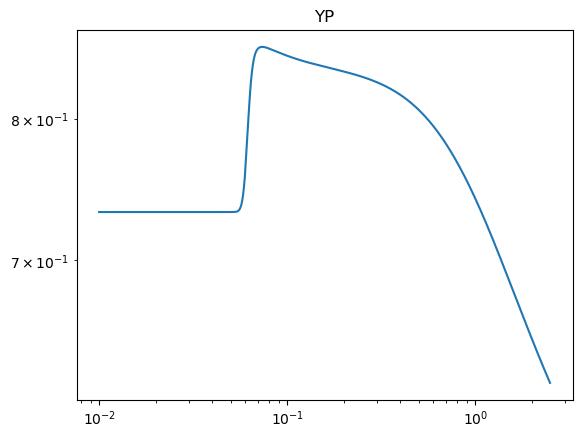

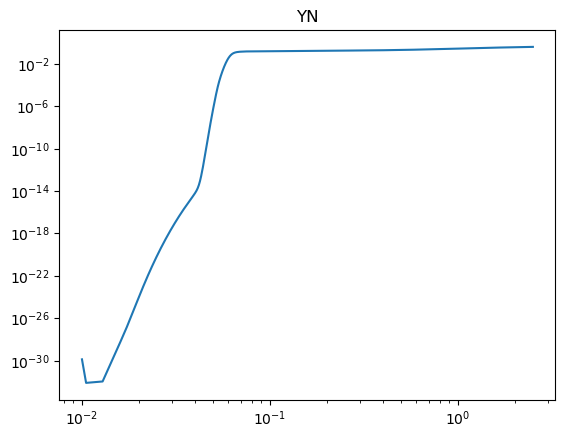

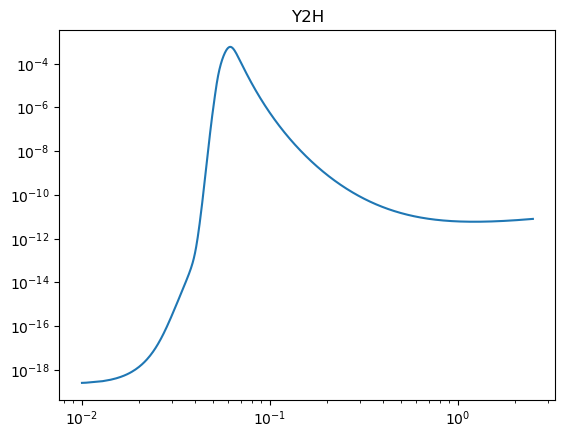

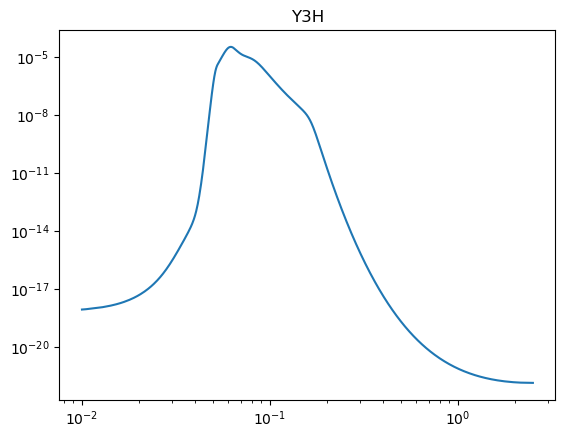

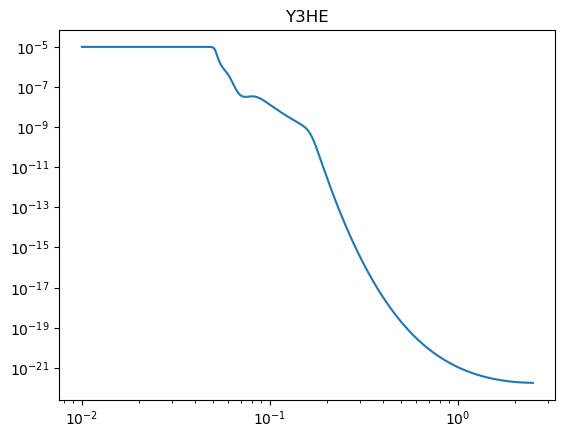

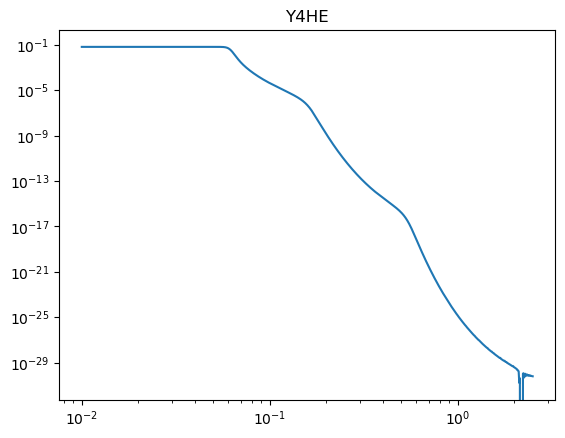

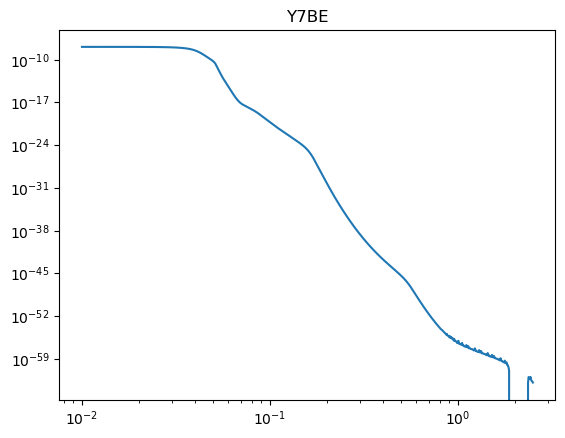

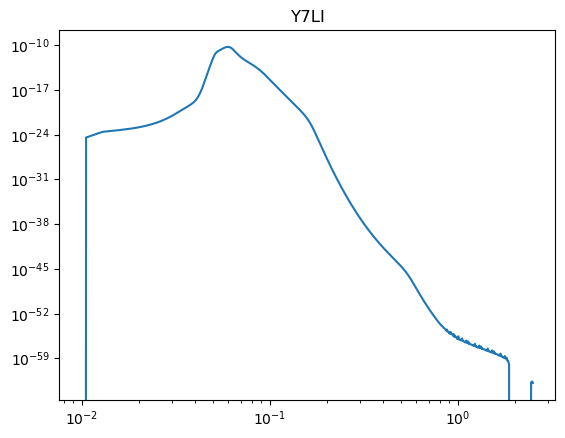

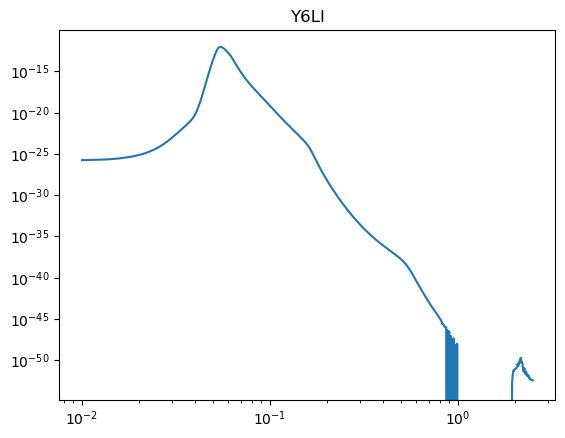

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure()
Tcm=1/a2
YP = np.zeros(len(a2))
YN = np.zeros(len(a2)) 
Y2H = np.zeros(len(a2)) 
Y3H = np.zeros(len(a2)) 
Y3HE = np.zeros(len(a2)) 
Y4HE = np.zeros(len(a2)) 
Y7BE = np.zeros(len(a2)) 
Y7LI = np.zeros(len(a2)) 
Y6LI = np.zeros(len(a2)) 
nseval=np.zeros((9,len(a2)))
    
for i in range(len(a2)):
    
    YP[i] = y2[i,3]
    YN[i] = y2[i,4]
    Y2H[i] = y2[i,5]
    Y3H[i] = y2[i,6]
    Y3HE[i] = y2[i,7]
    Y4HE[i] = y2[i,8]
    Y7BE[i] = y2[i,9]
    Y7LI[i] = y2[i,10]
    Y6LI[i] = y2[i,11]

    nseval[:,i] = nse.nse(y2[i,0] , y2[i,2] , y2[i,3] , y2[i,4])
plt.figure()
plt.loglog(Tcm,YP)
plt.title("YP")
plt.figure()
plt.loglog(Tcm,YN)
plt.title("YN")
plt.figure()
plt.loglog(Tcm,Y2H)
plt.title("Y2H")
plt.figure()
plt.loglog(Tcm,Y3H )
plt.title("Y3H")
plt.figure()
plt.loglog(Tcm,Y3HE )
plt.title("Y3HE")
plt.figure()
plt.loglog(Tcm,Y4HE )
plt.title("Y4HE")
plt.figure()
plt.loglog(Tcm, Y7BE)
plt.title("Y7BE")
plt.figure()
plt.loglog(Tcm,Y7LI )
plt.title("Y7LI")
plt.figure()
plt.loglog(Tcm,Y6LI)
plt.title("Y6LI")
plt.figure()
#plt.loglog(Tcm, nseval[2,:])



#for i in range():
   # plt.loglog(Tcm, nseval[i,:])
    #plt.ylim(10e-55,10e5)
#der.f(a0,y0,2)

<Figure size 640x480 with 0 Axes>

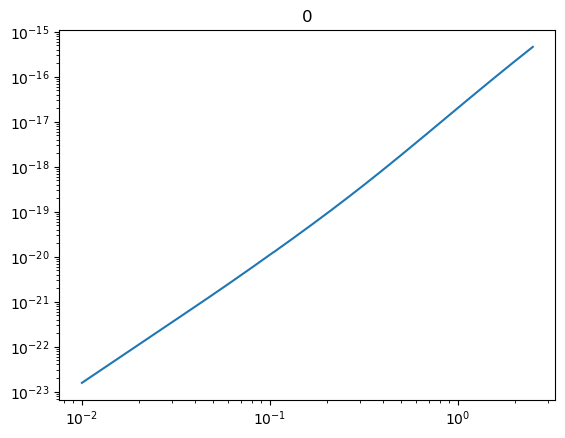

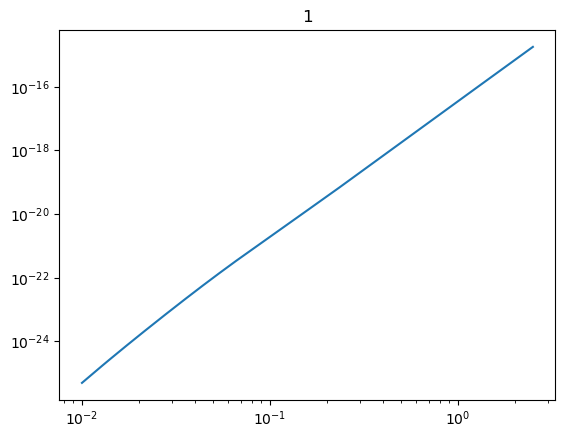

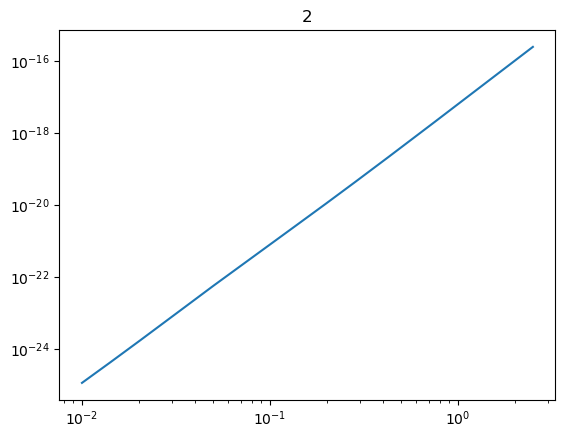

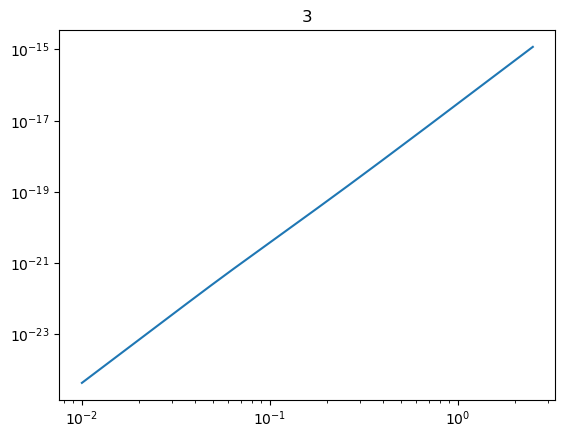

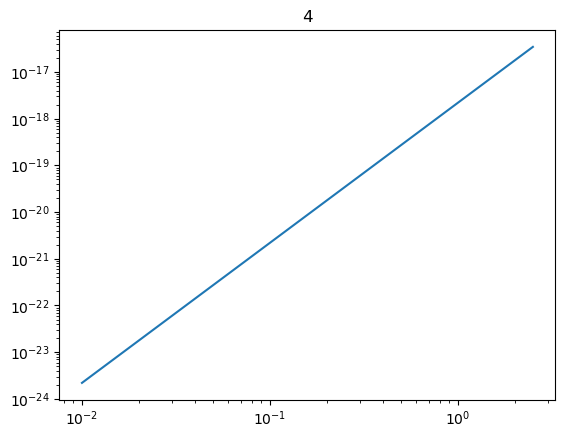

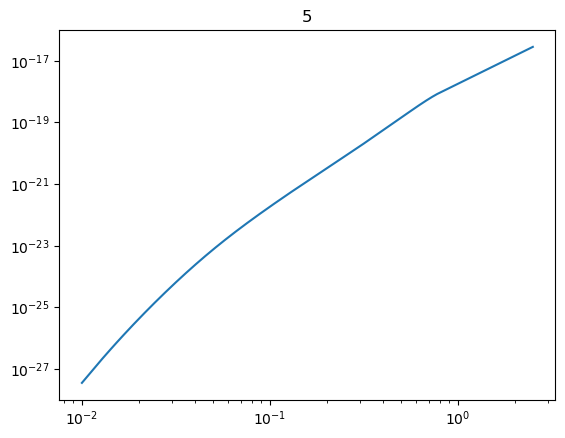

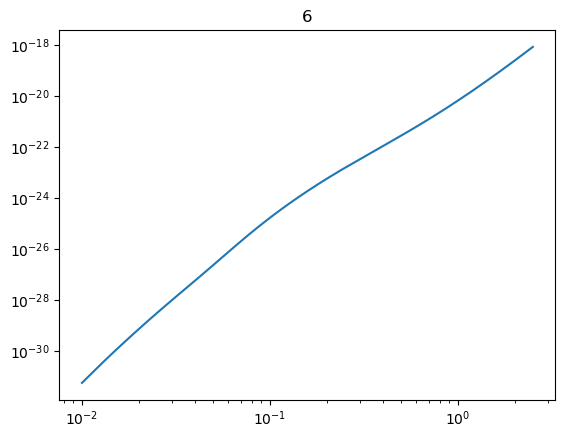

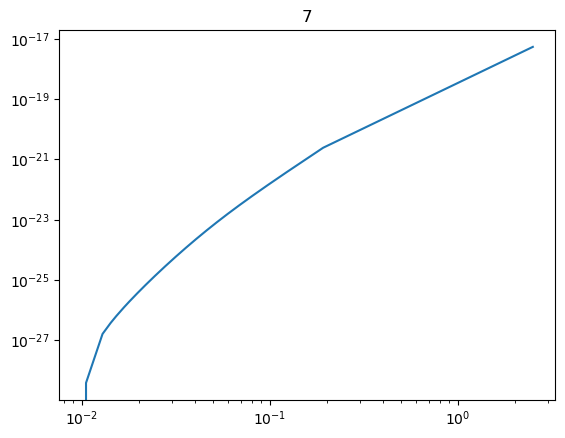

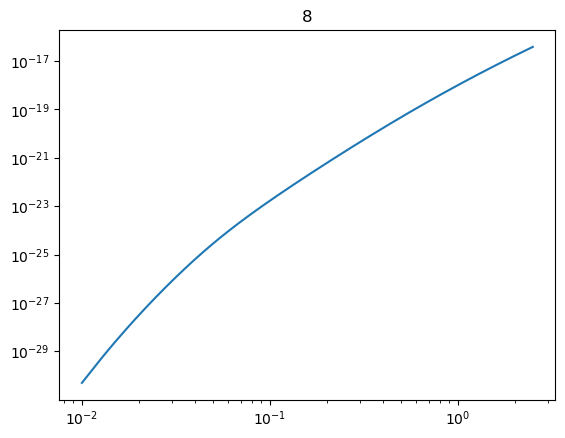

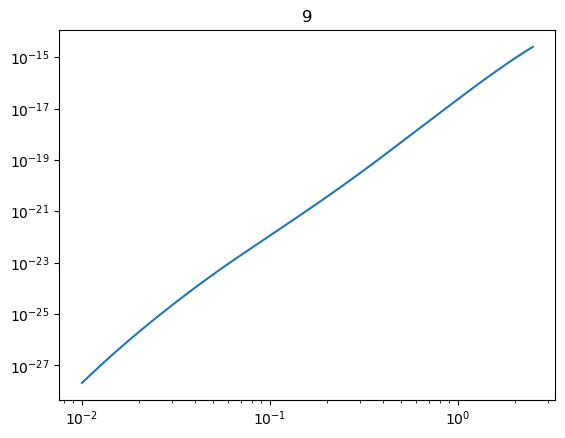

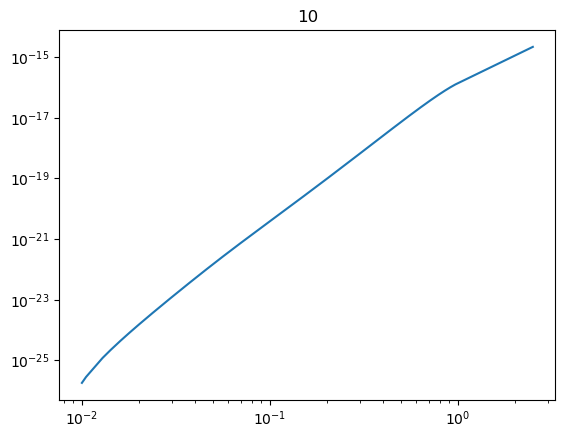

In [21]:
T2 = y2[:,0]
eta2 = y2[:,2]

Gamma_f_XG = np.zeros((xg.Nrxn,len(a2)))
Gamma_r_XG = np.zeros((xg.Nrxn,len(a2)))
Gamma_f_XY = np.zeros((xy.Nrxn,len(a2)))
Gamma_r_XY = np.zeros((xy.Nrxn,len(a2)))
Tcm = 1/a2
plt.figure()

for i in range(len(a2)):
    Gamma_f_XG[:,i], Gamma_r_XG[:,i] = xg.Gammaxg(T2[i], eta2[i])

for i in range(xg.Nrxn):
    plt.figure()
    plt.loglog(Tcm, Gamma_f_XG[i,:])
    plt.title(i)
   # plt.figure()
  #  plt.loglog(Tcm, Gamma_r_XG[i,:])
 #   plt.title(i)


for i in range(len(a2)):
    Gamma_f_XY[:,i], Gamma_r_XY[:,i] = xy.Gammaxy(T2[i], eta2[i])
  
#for i in range(xy.Nrxn): 
    #plt.figure()
    #plt.loglog(Tcm, Gamma_f_XY[i,:])
    #plt.title(i)
    #plt.figure()
  #  plt.loglog(Tcm, Gamma_r_XY[i,:])
  #  plt.title(i)

In [22]:
Anse = nse.nse(y2[0,0], y2[0,2], y2[0,3],y2[0,4])
print(Gamma_r_XG[0,0])
print(Gamma_f_XG[0,0]*((Anse[0]*Anse[1])/Anse[2]))



1.3759418992439687e-05
1.3759418992439687e-05


In [23]:
a[-1] = a2[0]
y[-1,:] = y2[0,:]
a_total = np.concatenate((a[:-1],a2))   #creates an array pof all the ind var values
#len(a_total) = len(a)-1+len(a2)
y_total = np.concatenate((y[:-1,:],y2),axis = 0) #creates a matrix of dep var values
#y_total.shape is len(a_total) x 12

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

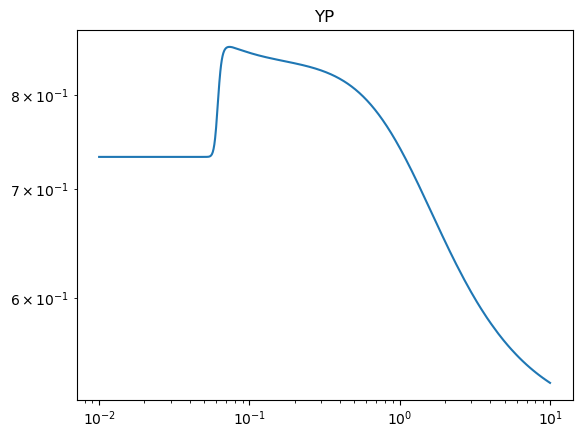

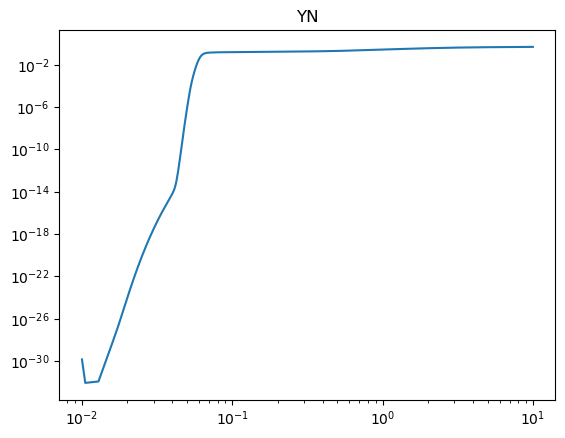

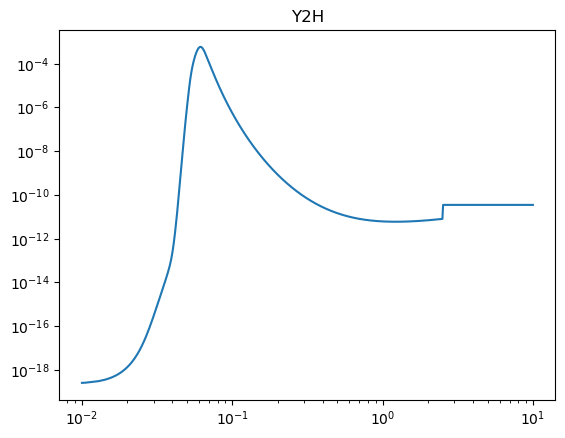

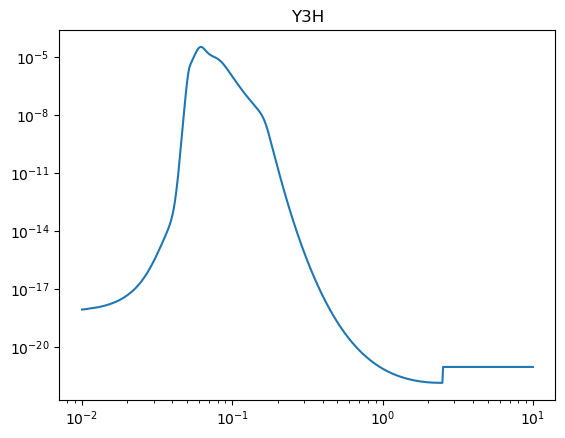

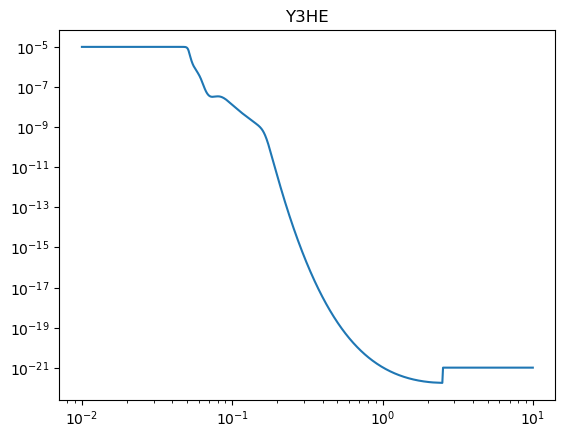

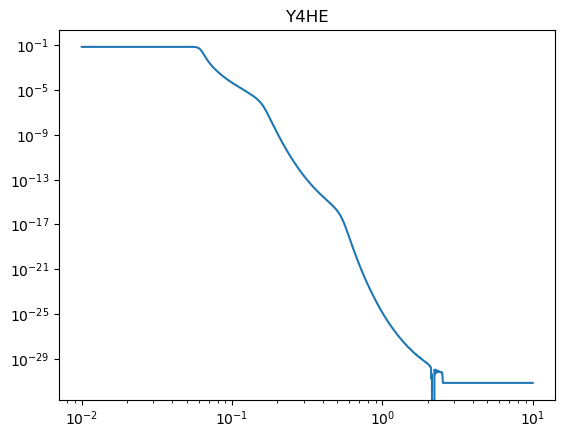

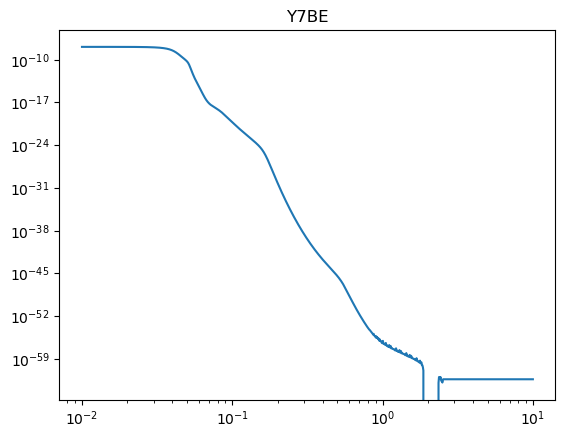

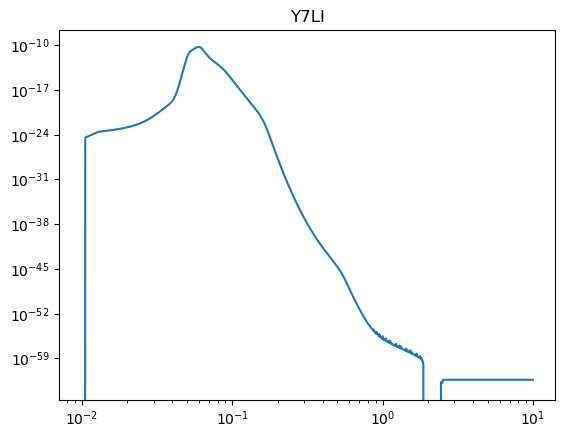

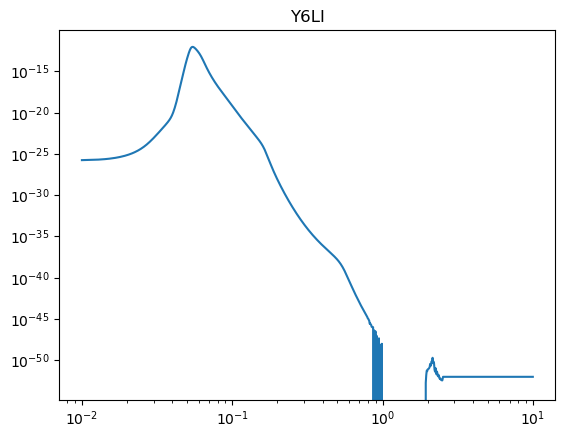

<Figure size 640x480 with 0 Axes>

In [24]:
plt.figure()
Tcm=1/a_total
YP = np.zeros(len(a_total))
YN = np.zeros(len(a_total)) 
Y2H = np.zeros(len(a_total)) 
Y3H = np.zeros(len(a_total)) 
Y3HE = np.zeros(len(a_total)) 
Y4HE = np.zeros(len(a_total)) 
Y7BE = np.zeros(len(a_total)) 
Y7LI = np.zeros(len(a_total)) 
Y6LI = np.zeros(len(a_total)) 
nseval=np.zeros((9,len(a_total)))
    
for i in range(len(a_total)):
    
    YP[i] = y_total[i,3]
    YN[i] = y_total[i,4]
    Y2H[i] = y_total[i,5]
    Y3H[i] = y_total[i,6]
    Y3HE[i] = y_total[i,7]
    Y4HE[i] = y_total[i,8]
    Y7BE[i] = y_total[i,9]
    Y7LI[i] = y_total[i,10]
    Y6LI[i] = y_total[i,11]

    nseval[:,i] = nse.nse(y_total[i,0] , y_total[i,2] , y_total[i,3] , y_total[i,4])
plt.figure()
plt.loglog(Tcm,YP)
plt.title("YP")
plt.figure()
plt.loglog(Tcm,YN)
plt.title("YN")
plt.figure()
plt.loglog(Tcm,Y2H)
plt.title("Y2H")
plt.figure()
plt.loglog(Tcm,Y3H )
plt.title("Y3H")
plt.figure()
plt.loglog(Tcm,Y3HE )
plt.title("Y3HE")
plt.figure()
plt.loglog(Tcm,Y4HE )
plt.title("Y4HE")
plt.figure()
plt.loglog(Tcm, Y7BE)
plt.title("Y7BE")
plt.figure()
plt.loglog(Tcm,Y7LI )
plt.title("Y7LI")
plt.figure()
plt.loglog(Tcm,Y6LI)
plt.title("Y6LI")
plt.figure()
#plt.loglog(Tcm, nseval[2,:])



#for i in range():
   # plt.loglog(Tcm, nseval[i,:])
    #plt.ylim(10e-55,10e5)
#der.f(a0,y0,2)

In [ ]:
T_total = y_total[:,0]
eta_total = y_total[:,2]

Gamma_f_XG = np.zeros((xg.Nrxn,len(a_total)))
Gamma_r_XG = np.zeros((xg.Nrxn,len(a_total)))
Gamma_f_XY = np.zeros((xy.Nrxn,len(a_total)))
Gamma_r_XY = np.zeros((xy.Nrxn,len(a_total)))
Tcm = 1/a_total
plt.figure()

for i in range(len(a_total)):
    Gamma_f_XG[:,i], Gamma_r_XG[:,i] = xg.Gammaxg(T_total[i], eta_total[i])

for i in range(xg.Nrxn):
    plt.figure()
    plt.loglog(Tcm, Gamma_f_XG[i,:])
    plt.title(i)
   # plt.figure()
  #  plt.loglog(Tcm, Gamma_r_XG[i,:])
 #   plt.title(i)


for i in range(len(a_total)):
    Gamma_f_XY[:,i], Gamma_r_XY[:,i] = xy.Gammaxy(T_total[i], eta_total[i])

#for i in range(xy.Nrxn): 
   # plt.figure()
   # plt.loglog(Tcm, Gamma_f_XY[i,:])
   # plt.title(i)

In [26]:


def he3tgli6(T):
    T9 = T*MeVtoT9
    F = .2201e6*(T9**(-2/3))*np.exp(-7.73436/(T9**(1./3.)))*(1.+5.38722e-2*(T9**(1./3.))-.214*(1.+.377*(T9**(1./3.)))*(T9**(2./3.))+.2733*(1.+.959*(T9**(1./3.)))*(T9**(4./3.))-1.53e-2*(1.+.959*(T9**(1./3.)))*T9*T9)*(1.-.213646*(T9**(2./3.))+.136643*(T9**(4./3.))-7.65244e-3*T9*T9)
    return F*cmgstoMeV*mN
   
   
    
T = y_total[:,0]

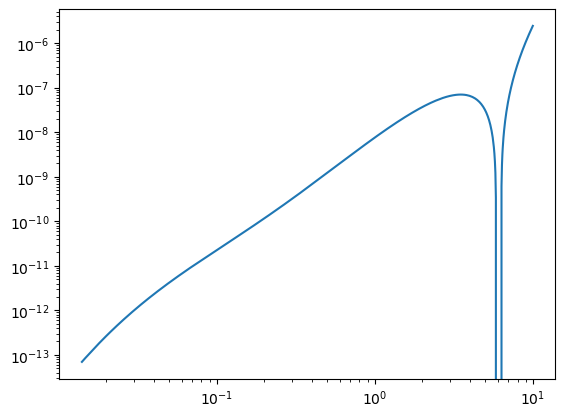

In [27]:
plt.figure()
plt.loglog(T, he3tgli6(T))

In [28]:
T[np.argmax(ddpt(T))]

NameError: name 'ddpt' is not defined

In [ ]:
np.max(ddpt(T))

In [78]:
T = 1.5766907780386983
T9 = T*MeVtoT9
print(T9)

18.29674756074093


In [80]:
1.2225868501433263e-05/(cmgstoMeV*mN)

85567388.72783639